In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
train_dir = "dataset/train"

In [4]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [5]:
full_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)

Total images: 50000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 40000
Val: 10000


In [7]:
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [8]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Balanced init (IMPORTANT)
        self.gate_scores = nn.Parameter(torch.full((out_features, in_features), -1.0))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return torch.nn.functional.linear(x, pruned_weights, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [9]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

    def get_all_gates(self):
        gates = []
        for m in self.modules():
            if isinstance(m, PrunableLinear):
                gates.append(m.get_gates().view(-1))
        return torch.cat(gates)

    def sparsity(self, threshold=0.2):
        g = self.get_all_gates()
        return (g < threshold).float().mean().item() * 100

In [10]:
def compute_sparsity_loss(model):
    sp_loss = 0
    layer_count = 0

    for m in model.modules():
        if isinstance(m, PrunableLinear):
            gates = m.get_gates()
            sp_loss += torch.mean(gates)
            layer_count += 1

    return sp_loss / layer_count

In [11]:
def get_lambda(epoch, target_lambda, warmup_epochs=5):
    if epoch < warmup_epochs:
        return target_lambda * (epoch + 1) / warmup_epochs
    return target_lambda

In [12]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100 * correct / total
    return acc, all_preds, all_labels

In [13]:
import torch
import pickle
import os

os.makedirs("saved_models", exist_ok=True)

LAMBDA_VALUES = [0.0, 0.1, 0.5, 2.0]
NUM_EPOCHS = 25
SPARSITY_THRESHOLD = 0.2
SPARSITY_SCALE = 5

results = {}

for lam in LAMBDA_VALUES:
    print(f"\nTraining with Lambda = {lam}")

    model = PrunableNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0
    best_model_state = None

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0

        current_lambda = get_lambda(epoch, lam)

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            ce_loss = criterion(outputs, labels)
            sp_loss = compute_sparsity_loss(model)

            loss = ce_loss + current_lambda * SPARSITY_SCALE * sp_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        acc, preds, labels = evaluate(model, val_loader)
        sparsity = model.sparsity(threshold=SPARSITY_THRESHOLD)

        # 🔹 Track best model
        if acc > best_acc:
            best_acc = acc
            best_model_state = model.state_dict()

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Acc={acc:.2f}%, Sparsity={sparsity:.2f}%")

    # 🔹 Load best model
    model.load_state_dict(best_model_state)

    final_acc, preds, labels = evaluate(model, val_loader)
    final_sparsity = model.sparsity(threshold=SPARSITY_THRESHOLD)

    # 🔹 Save model (IMPORTANT)
    model_path = f"saved_models/model_lambda_{lam}.pkl"
    torch.save(model.state_dict(), model_path)

    # 🔹 Save results
    results[lam] = {
        "acc": final_acc,
        "sparsity": final_sparsity
    }

    # 🔹 Save individual result file (safe backup)
    with open(f"saved_models/results_lambda_{lam}.pkl", "wb") as f:
        pickle.dump(results[lam], f)

    print(f"\nFinal: Acc={final_acc:.2f}% | Sparsity={final_sparsity:.2f}%")
    print(f"Saved model → {model_path}")

# 🔹 Save all results together
with open("saved_models/all_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("\nAll models and results saved successfully!")


Training with Lambda = 0.0
Epoch 1: Loss=1.9012, Acc=37.33%, Sparsity=0.00%
Epoch 2: Loss=1.6536, Acc=41.97%, Sparsity=0.00%
Epoch 3: Loss=1.5431, Acc=44.93%, Sparsity=0.00%
Epoch 4: Loss=1.4621, Acc=47.49%, Sparsity=0.00%
Epoch 5: Loss=1.3924, Acc=49.16%, Sparsity=0.00%
Epoch 6: Loss=1.3293, Acc=50.65%, Sparsity=0.00%
Epoch 7: Loss=1.2772, Acc=51.14%, Sparsity=0.00%
Epoch 8: Loss=1.2239, Acc=52.19%, Sparsity=0.00%
Epoch 9: Loss=1.1762, Acc=52.93%, Sparsity=0.01%
Epoch 10: Loss=1.1314, Acc=52.70%, Sparsity=0.02%
Epoch 11: Loss=1.0899, Acc=53.44%, Sparsity=0.03%
Epoch 12: Loss=1.0499, Acc=53.31%, Sparsity=0.07%
Epoch 13: Loss=1.0090, Acc=53.72%, Sparsity=0.12%
Epoch 14: Loss=0.9723, Acc=53.30%, Sparsity=0.19%
Epoch 15: Loss=0.9342, Acc=53.70%, Sparsity=0.29%
Epoch 16: Loss=0.8979, Acc=53.64%, Sparsity=0.40%
Epoch 17: Loss=0.8641, Acc=52.84%, Sparsity=0.55%
Epoch 18: Loss=0.8345, Acc=53.30%, Sparsity=0.71%
Epoch 19: Loss=0.8006, Acc=53.25%, Sparsity=0.90%
Epoch 20: Loss=0.7670, Acc=52.6

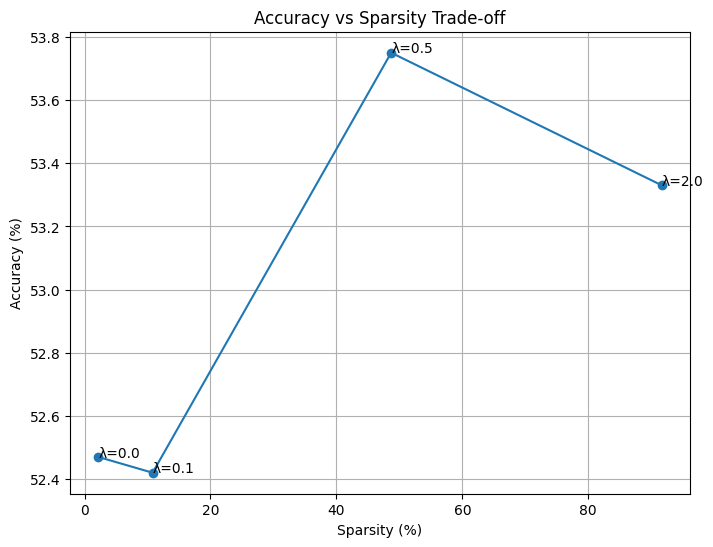

In [16]:
# ================================
# GRAPHS FOR ANALYSIS (FIXED)
# ================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔹 1. Accuracy vs Sparsity

lams = sorted(results.keys())
accs = [results[l]["acc"] for l in lams]
sparsities = [results[l]["sparsity"] for l in lams]

plt.figure(figsize=(8,6))
plt.plot(sparsities, accs, marker='o')

for i, lam in enumerate(lams):
    plt.text(sparsities[i], accs[i], f"λ={lam}")

plt.xlabel("Sparsity (%)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Sparsity Trade-off")
plt.grid()
plt.show()

